# 04. 72시간 의사결정 지원 (Decision Support)

운영자의 아침 상황: 현재 댐수위, 하류 주요지점 유량, 그리고 기상예보에 따른 **72시간 hourly 유입량 예측**이 주어집니다(요구사항 3, 6). 이 노트북은

1. 학습된 정책으로 향후 72시간 방류 계획을 만들고,
2. 예측 불확실성을 **앙상블(예측 실현 N개)** 로 반영해 수위·하류유량의 신뢰구간과 위험 확률을 계산하며,
3. 운영자 선호(상한/중간/하한)별 권고안을 나란히 비교하는

의사결정 표를 생성합니다.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
sys.path.insert(0, ".")
import hourly_reservoir as hr, ppo_lagrangian as pl
plt.rcParams["figure.figsize"] = (12, 3.4)
model, env_kwargs = pl.load_policy("models/policy.pt")
agent = pl.PolicyAgent(model, greedy=True)

## 1. 상황 설정

7월 중순, 수위 113.2 m(밴드 111–114), 직전 방류 150 m³/s, 이틀 뒤 큰 강우가 예보된 상황을 만듭니다. 실제 운영에서는 이 셀이 SCADA·예보 시스템에서 값을 읽어오는 부분입니다.

In [2]:
SITUATION = dict(start_doy=196, init_level=113.2, prev_release=150.0, target_position=0.5)
env = hr.HourlyReservoirEnv(**env_kwargs)
obs, info = env.reset(seed=11, horizon_hours=72, **{k: v for k, v in SITUATION.items() if k != "prev_release"})
env.prev_release = SITUATION["prev_release"]
base_fc = env.hourly_fc[0].copy()                 # the 72 h forecast issued now
true_inflow = env.inflow[1:73].copy()             # what will actually happen (unknown to the operator)
print(f"level {env.level:.2f} m | band {env._band()[1]:.1f}–{env._band()[0]:.1f} m | downstream now {env.ds_flow:.0f} m³/s")
print(f"forecast: max {base_fc.max():.0f} m³/s at +{base_fc.argmax()+1} h | 72 h volume {base_fc.sum()*3600/1e6:.0f} 1e6 m³ | free storage to design flood {hr.storage_from_level(hr.Z_DESIGN_FLOOD)-hr.storage_from_level(env.level):.0f} 1e6 m³")

level 113.20 m | band 111.0–114.0 m | downstream now 184 m³/s
forecast: max 3211 m³/s at +66 h | 72 h volume 109 1e6 m³ | free storage to design flood 680 1e6 m³


## 2. 정책으로 72시간 계획 만들기

정책은 매 시각 관측(수위, 하류유량, 예측)을 보고 방류를 정합니다. 계획을 만들 때는 예측을 "실제 유입"으로 가정하고 72시간을 굴립니다. 앙상블에서는 예측에 리드타임 의존 오차를 다시 씌워 N개의 실현을 만듭니다.

In [3]:
def plan_72h(policy, situation, inflow_realisation, forecast, seed=0):
    """Roll the policy for 72 h. `inflow_realisation` is treated as the truth; `forecast` is what the policy sees at t=0
    (re-issued every hour from the realisation with fresh error, like a real forecast system)."""
    e = hr.HourlyReservoirEnv(**env_kwargs)
    n = 72 + hr.FC_HOURS + 24 * (hr.FC_DAYS + 4)
    inflow = np.concatenate([[inflow_realisation[0]], inflow_realisation, np.full(n - 73, inflow_realisation[-1])])
    obs, info = e.reset(seed=seed, horizon_hours=72, inflow=inflow, forecast_seed=seed,
                        **{k: v for k, v in situation.items() if k != "prev_release"})
    e.hourly_fc[0] = forecast                     # the operator's current forecast
    e.prev_release = situation["prev_release"]
    info["action_mask"] = e.action_mask()
    done = False
    while not done:
        a = policy(obs, info["action_mask"])
        obs, r, te, tr, info = e.step(a); done = te or tr
    return pd.DataFrame(e.history)

def ensemble(policy, situation, forecast, n=30, seed=0):
    """Perturb the forecast with lead-dependent error to get n plausible inflow realisations, plan on each."""
    rng = np.random.default_rng(seed)
    sig = 0.08 + 0.27 * np.arange(1, 73) / 72
    runs = []
    for i in range(n):
        eps = rng.normal() * np.sqrt(.6) + rng.normal(size=72) * np.sqrt(.4)
        real = forecast * np.exp(sig * eps - 0.5 * sig ** 2)
        runs.append(plan_72h(policy, situation, real, forecast, seed=i))
    return runs

plan = plan_72h(agent, SITUATION, base_fc, base_fc)
runs = ensemble(agent, SITUATION, base_fc, n=30)
plan[["t", "level_next", "release", "ds_flow", "flood_cost", "drought_cost", "mask_relaxed"]].head(8)

,t,level_next,release,ds_flow,flood_cost,drought_cost,mask_relaxed
0,0,113.183534,384.429762,210.238206,0.0,0.0,
1,1,113.155669,542.740592,210.238206,0.0,0.0,
2,2,113.128316,542.740592,210.238206,0.0,0.0,
3,3,113.100854,542.740592,292.769166,0.0,0.0,
4,4,113.072819,542.740592,399.677577,0.0,0.0,
5,5,113.045012,542.740592,466.727337,0.0,0.0,
6,6,113.018260,542.740592,513.225494,0.0,0.0,
7,7,112.986486,542.740592,547.858676,0.0,0.0,


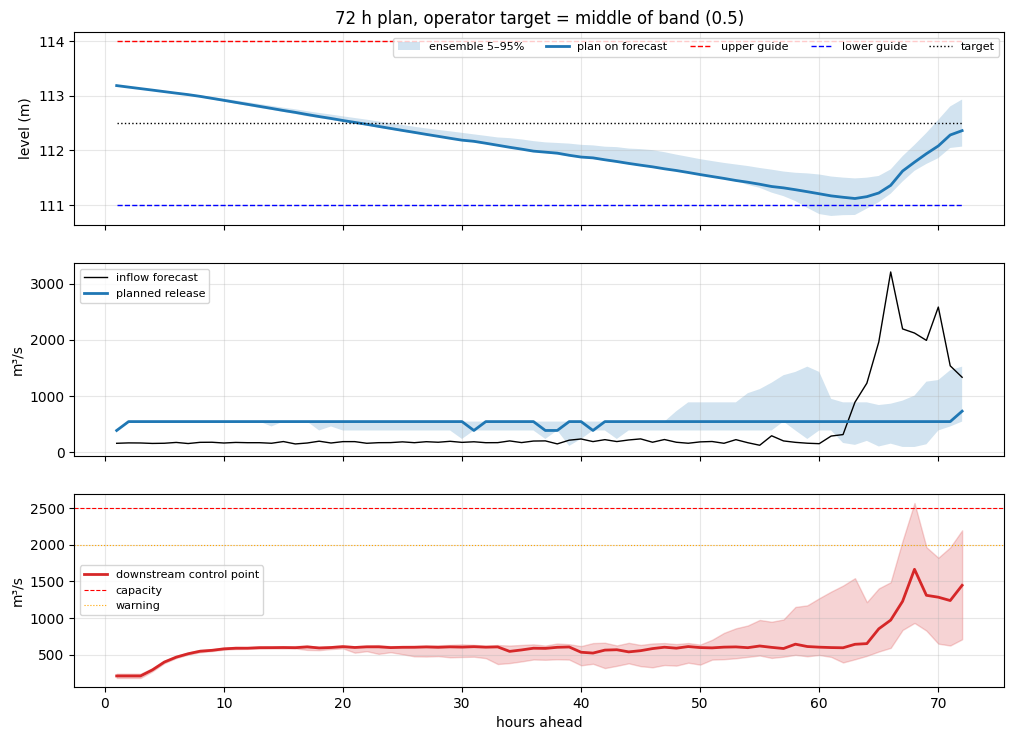

In [4]:
def plot_plan(plan, runs, title):
    L = np.array([r.level_next.values for r in runs]); R = np.array([r.release.values for r in runs]); D = np.array([r.ds_flow.values for r in runs])
    h = np.arange(1, 73)
    fig, axes = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)
    axes[0].fill_between(h, np.percentile(L, 5, 0), np.percentile(L, 95, 0), alpha=.2, label="ensemble 5–95%"); axes[0].plot(h, plan.level_next, lw=2, label="plan on forecast")
    axes[0].plot(h, plan.upper, "r--", lw=1, label="upper guide"); axes[0].plot(h, plan.lower, "b--", lw=1, label="lower guide"); axes[0].plot(h, plan.target, "k:", lw=1, label="target"); axes[0].set_ylabel("level (m)"); axes[0].legend(ncol=5, fontsize=8); axes[0].set_title(title)
    axes[1].plot(h, base_fc, "k", lw=1, label="inflow forecast"); axes[1].fill_between(h, np.percentile(R, 5, 0), np.percentile(R, 95, 0), alpha=.2); axes[1].plot(h, plan.release, lw=2, label="planned release"); axes[1].set_ylabel("m³/s"); axes[1].legend(fontsize=8)
    axes[2].fill_between(h, np.percentile(D, 5, 0), np.percentile(D, 95, 0), alpha=.2, color="tab:red"); axes[2].plot(h, plan.ds_flow, c="tab:red", lw=2, label="downstream control point"); axes[2].axhline(hr.Q_DS_SAFE, c="r", ls="--", lw=.8, label="capacity"); axes[2].axhline(hr.Q_DS_WARN, c="orange", ls=":", lw=.8, label="warning"); axes[2].set_ylabel("m³/s"); axes[2].set_xlabel("hours ahead"); axes[2].legend(fontsize=8)
    for a in axes: a.grid(alpha=.3)

plot_plan(plan, runs, "72 h plan, operator target = middle of band (0.5)")

## 3. 의사결정 표

운영자에게 보여줄 요약입니다. 위험 확률은 앙상블에서 해당 사건이 발생한 비율입니다. 발전량은 참고 정보로만 표시합니다(제약 아님).

In [5]:
def decision_table(plan, runs, situation):
    L = np.array([r.level_next.values for r in runs]); D = np.array([r.ds_flow.values for r in runs])
    up = plan.upper.values; lo = plan.lower.values
    return pd.Series({
        "recommended release next hour (m³/s)": plan.release.iloc[0],
        "recommended release next 6 h (m³/s)": plan.release.iloc[:6].mean(),
        "recommended release 6–24 h (m³/s)": plan.release.iloc[6:24].mean(),
        "recommended release 24–72 h (m³/s)": plan.release.iloc[24:].mean(),
        "allowed range next hour (m³/s)": tuple(np.round(env.grid[env.action_mask()][[0, -1]], 0)),
        "expected level +24 h / +72 h (m)": (round(plan.level_next.iloc[23], 2), round(plan.level_next.iloc[71], 2)),
        "P(level > upper guide within 72 h)": (L > up).any(1).mean(),
        "P(level > design flood level)": (L > hr.Z_DESIGN_FLOOD).any(1).mean(),
        "P(downstream > capacity)": (D > hr.Q_DS_SAFE).any(1).mean(),
        "P(downstream > warning)": (D > hr.Q_DS_WARN).any(1).mean(),
        "P(level < lower guide within 72 h)": (L < lo).any(1).mean(),
        "level 72 h  5–95% (m)": tuple(np.round(np.percentile(L[:, -1], [5, 95]), 2)),
        "peak downstream 5–95% (m³/s)": tuple(np.round(np.percentile(D.max(1), [5, 95]), 0)),
        "max hourly ramp in plan (m³/s)": plan.release.diff().abs().max(),
        "hours with relaxed mask layer": int((plan.mask_relaxed != "").sum()),
        "energy 72 h (MWh, info only)": plan.power_mw.sum(),
    })

decision_table(plan, runs, SITUATION)

recommended release next hour (m³/s)          384.429762
recommended release next 6 h (m³/s)           516.355453
recommended release 6–24 h (m³/s)             542.740592
recommended release 24–72 h (m³/s)            533.419755
allowed range next hour (m³/s)             (19.0, 421.0)
expected level +24 h / +72 h (m)         (112.4, 112.36)
P(level > upper guide within 72 h)                   0.0
P(level > design flood level)                        0.0
P(downstream > capacity)                             0.1
P(downstream > warning)                         0.266667
P(level < lower guide within 72 h)              0.166667
level 72 h  5–95% (m)                   (112.07, 112.93)
peak downstream 5–95% (m³/s)             (973.0, 2572.0)
max hourly ramp in plan (m³/s)                185.843149
hours with relaxed mask layer                          0
energy 72 h (MWh, info only)                 9025.678185
dtype: object

## 4. 운영자 선호별 비교 (요구사항 5)

같은 상황에서 `target_position` 만 0.2 / 0.5 / 0.8 로 바꿉니다. 하나의 학습된 정책이 세 경우를 모두 처리합니다.

In [6]:
cols = {}
plans = {}
for tp, label in ((0.2, "near lower (0.2)"), (0.5, "middle (0.5)"), (0.8, "near upper (0.8)")):
    sit = dict(SITUATION, target_position=tp)
    p = plan_72h(agent, sit, base_fc, base_fc); rs = ensemble(agent, sit, base_fc, n=30)
    plans[tp] = (p, rs); cols[label] = decision_table(p, rs, sit)
pd.DataFrame(cols)

,near lower (0.2),middle (0.5),near upper (0.8)
recommended release next hour (m³/s),384.429762,384.429762,384.429762
recommended release next 6 h (m³/s),516.355453,516.355453,437.200038
recommended release 6–24 h (m³/s),542.740592,542.740592,393.224808
recommended release 24–72 h (m³/s),542.740592,533.419755,549.283102
allowed range next hour (m³/s),"(19.0, 421.0)","(19.0, 421.0)","(19.0, 421.0)"
expected level +24 h / +72 h (m),"(112.4, 112.32)","(112.4, 112.36)","(112.71, 112.6)"
P(level > upper guide within 72 h),0.0,0.0,0.0
P(level > design flood level),0.0,0.0,0.0
P(downstream > capacity),0.1,0.1,0.1
P(downstream > warning),0.266667,0.266667,0.333333


Text(0.5, 1.0, '72 h level plans by operator preference')

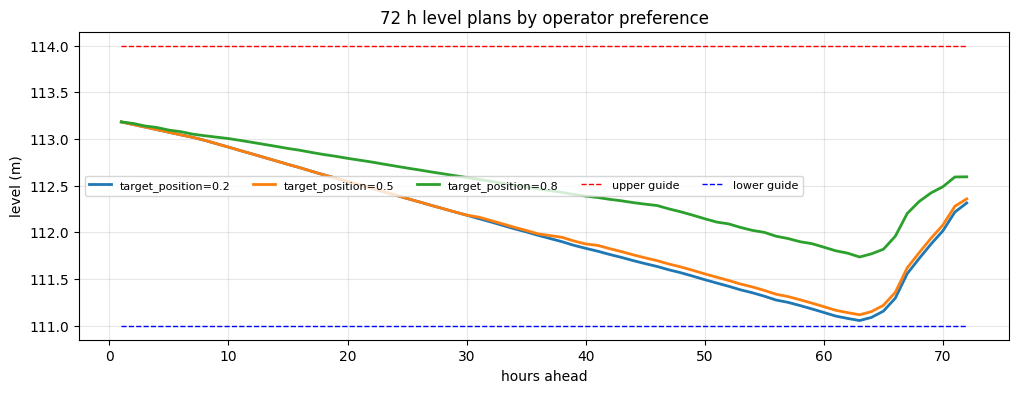

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
h = np.arange(1, 73)
for tp, (p, rs) in plans.items():
    ax.plot(h, p.level_next, lw=2, label=f"target_position={tp}")
ax.plot(h, p.upper, "r--", lw=1, label="upper guide"); ax.plot(h, p.lower, "b--", lw=1, label="lower guide")
ax.set_xlabel("hours ahead"); ax.set_ylabel("level (m)"); ax.legend(ncol=5, fontsize=8); ax.grid(alpha=.3); ax.set_title("72 h level plans by operator preference")

## 5. 규칙 기반 계획과 비교

같은 상황에서 규칙(`TargetTrackingRule`)이 만든 계획과 정책의 계획을 홍수 지표 중심으로 비교합니다.

In [8]:
class RuleOnEnv:
    def __call__(self, obs, mask):  # the rule needs the env instance, which plan_72h creates internally; wrap lazily
        return self.rule(obs, mask)

def plan_rule(situation, real, forecast, seed=0):
    holder = RuleOnEnv()
    def pol(obs, mask):
        return holder.rule(obs, mask)
    # replicate plan_72h but bind the rule to the env it creates
    e = hr.HourlyReservoirEnv(**env_kwargs)
    n = 72 + hr.FC_HOURS + 24 * (hr.FC_DAYS + 4)
    inflow = np.concatenate([[real[0]], real, np.full(n - 73, real[-1])])
    obs, info = e.reset(seed=seed, horizon_hours=72, inflow=inflow, forecast_seed=seed, **{k: v for k, v in situation.items() if k != "prev_release"})
    e.hourly_fc[0] = forecast; e.prev_release = situation["prev_release"]; info["action_mask"] = e.action_mask()
    holder.rule = hr.TargetTrackingRule(e)
    done = False
    while not done:
        obs, r, te, tr, info = e.step(pol(obs, info["action_mask"])); done = te or tr
    return pd.DataFrame(e.history)

rule_plan = plan_rule(SITUATION, base_fc, base_fc)
cmp = pd.DataFrame({"policy": hr.summarize(plan), "rule": hr.summarize(rule_plan)})
cmp.loc[["flood_hours_above_upper", "downstream_over_capacity_hours", "downstream_max_flow", "drought_hours_below_lower", "mean_abs_target_dev_m", "max_hourly_ramp", "mask_relaxed_hours", "energy_GWh"]].round(2)

,policy,rule
flood_hours_above_upper,0.00,0.00
downstream_over_capacity_hours,0.00,0.00
downstream_max_flow,1666.51,2477.76
drought_hours_below_lower,0.00,0.00
mean_abs_target_dev_m,0.61,0.62
max_hourly_ramp,185.84,271.02
mask_relaxed_hours,0.00,0.00
energy_GWh,9.03,8.49


## 6. 실제 운영에서의 사용 절차

1. 매 시각(또는 6시간마다) SCADA 에서 수위·방류·하류유량, 예보 시스템에서 72h 유입 예측을 읽어 `SITUATION` 과 `base_fc` 를 채웁니다.
2. `decision_table` 을 운영자 화면에 표시합니다. **권고 방류량은 허용 범위 안에 있으며, 허용 범위 자체가 규정(마스크)을 보장**합니다.
3. 운영자는 `target_position` 을 바꿔 선호에 맞는 계획을 고르고, 승인 후 방류를 결정합니다.
4. 위험 확률(`P(...)`) 이 기준(예: 하류 계획홍수량 초과 확률 10%)을 넘으면 홍수 비상 절차로 전환합니다.
5. 모든 입력·권고·결정을 로그로 남깁니다(부록 E 형식 참고).